In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║     SAC  ·  MuJoCo Humanoid-v5  ·  TRAINING                    ║
# ╚══════════════════════════════════════════════════════════════════╝
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import copy
import sys

# ── Config ────────────────────────────────────────────────────────────────────
STATE_DIM  = 348       # Humanoid-v5 observation space (v4: 376 → v5: 348)
ACTION_DIM = 17        # 17 joint torques
MAX_ACTION = 0.4       # Humanoid action range [-0.4, 0.4]

learning_rate   = 3e-4
gamma           = 0.99
tau             = 0.005
alpha_init      = 0.2
batch_size      = 256
buffer_size     = 500_000
start_episodes  = 30
TOTAL_EPISODES  = 4000
EVAL_INTERVAL   = 50
SAVE_INTERVAL   = 500
N_EVAL_EPISODES = 5

FINAL_PATH = 'sac_humanoid_final.pt'
BEST_PATH  = 'sac_humanoid_best.pt'
LOG_DIR    = f'runs/SAC_humanoid_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}', flush=True)
print(f'CUDA   : {torch.cuda.is_available()}', flush=True)
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}', flush=True)
print(f'Log dir: {LOG_DIR}', flush=True)

# ── Replay Buffer ─────────────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self):
        self.ptr  = 0
        self.size = 0
        self.s  = np.zeros((buffer_size, STATE_DIM),  dtype=np.float32)
        self.a  = np.zeros((buffer_size, ACTION_DIM), dtype=np.float32)
        self.r  = np.zeros((buffer_size, 1),          dtype=np.float32)
        self.s_ = np.zeros((buffer_size, STATE_DIM),  dtype=np.float32)
        self.d  = np.zeros((buffer_size, 1),          dtype=np.float32)

    def add(self, s, a, r, s_, done):
        self.s[self.ptr]  = s
        self.a[self.ptr]  = a
        self.r[self.ptr]  = r
        self.s_[self.ptr] = s_
        self.d[self.ptr]  = done
        self.ptr  = (self.ptr + 1) % buffer_size
        self.size = min(self.size + 1, buffer_size)

    def sample(self):
        idx = np.random.randint(0, self.size, batch_size)
        return (
            torch.FloatTensor(self.s[idx]).to(device),
            torch.FloatTensor(self.a[idx]).to(device),
            torch.FloatTensor(self.r[idx]).to(device),
            torch.FloatTensor(self.s_[idx]).to(device),
            torch.FloatTensor(self.d[idx]).to(device),
        )

# ── Actor (Stochastic) ────────────────────────────────────────────────────────
class Actor(nn.Module):
    LOG_STD_MIN = -20
    LOG_STD_MAX =   2

    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(STATE_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
        )
        self.mean_layer    = nn.Linear(256, ACTION_DIM)
        self.log_std_layer = nn.Linear(256, ACTION_DIM)

    def forward(self, s):
        x       = self.shared(s)
        mean    = self.mean_layer(x)
        log_std = self.log_std_layer(x).clamp(self.LOG_STD_MIN, self.LOG_STD_MAX)
        return mean, log_std

    def sample(self, s):
        mean, log_std = self.forward(s)
        std    = log_std.exp()
        eps    = torch.randn_like(mean)
        x      = mean + std * eps
        a      = torch.tanh(x)
        log_prob = (
            torch.distributions.Normal(mean, std).log_prob(x)
            - torch.log(1 - a.pow(2) + 1e-6)
        ).sum(dim=-1, keepdim=True)
        return MAX_ACTION * a, log_prob

    def deterministic_action(self, s):
        mean, _ = self.forward(s)
        return MAX_ACTION * torch.tanh(mean)

# ── Critic (Twin Q-networks) ──────────────────────────────────────────────────
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.q1 = nn.Sequential(
            nn.Linear(STATE_DIM + ACTION_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),                    nn.ReLU(),
            nn.Linear(256, 1),
        )
        self.q2 = nn.Sequential(
            nn.Linear(STATE_DIM + ACTION_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),                    nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, s, a):
        sa = torch.cat([s, a], dim=1)
        return self.q1(sa), self.q2(sa)

# ── SAC Agent ─────────────────────────────────────────────────────────────────
class SACAgent:
    def __init__(self):
        self.actor     = Actor().to(device)
        self.actor_opt = optim.Adam(self.actor.parameters(), lr=learning_rate)

        self.critic        = Critic().to(device)
        self.critic_target = copy.deepcopy(self.critic)
        self.critic_opt    = optim.Adam(self.critic.parameters(), lr=learning_rate)

        self.target_entropy = -float(ACTION_DIM)
        self.log_alpha      = torch.tensor(np.log(alpha_init), dtype=torch.float,
                                           requires_grad=True, device=device)
        self.alpha          = self.log_alpha.exp().item()
        self.alpha_opt      = optim.Adam([self.log_alpha], lr=learning_rate)

    def select_action(self, s, evaluate=False):
        s = torch.FloatTensor(s).unsqueeze(0).to(device)
        if evaluate:
            return self.actor.deterministic_action(s).cpu().data.numpy().flatten()
        a, _ = self.actor.sample(s)
        return a.cpu().data.numpy().flatten()

    def update(self, buf):
        s, a, r, s_, d = buf.sample()

        with torch.no_grad():
            a_, log_prob_ = self.actor.sample(s_)
            q1_, q2_      = self.critic_target(s_, a_)
            q_target = r + gamma * (1 - d) * (torch.min(q1_, q2_) - self.alpha * log_prob_)

        q1, q2      = self.critic(s, a)
        critic_loss = F.mse_loss(q1, q_target) + F.mse_loss(q2, q_target)
        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        a_new, log_prob = self.actor.sample(s)
        q1_new, q2_new  = self.critic(s, a_new)
        actor_loss = (self.alpha * log_prob - torch.min(q1_new, q2_new)).mean()
        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        alpha_loss = -(self.log_alpha * (log_prob.detach() + self.target_entropy)).mean()
        self.alpha_opt.zero_grad()
        alpha_loss.backward()
        self.alpha_opt.step()
        self.alpha = self.log_alpha.exp().item()

        for p, tp in zip(self.critic.parameters(), self.critic_target.parameters()):
            tp.data.copy_(tau * p.data + (1 - tau) * tp.data)

        return critic_loss.item(), actor_loss.item(), alpha_loss.item(), self.alpha

    def save(self, path):
        torch.save({
            'actor':         self.actor.state_dict(),
            'critic':        self.critic.state_dict(),
            'critic_target': self.critic_target.state_dict(),
            'log_alpha':     self.log_alpha.item(),
        }, path)

    def load(self, path):
        ckpt = torch.load(path, map_location=device)
        self.actor.load_state_dict(ckpt['actor'])
        self.critic.load_state_dict(ckpt['critic'])
        self.critic_target.load_state_dict(ckpt['critic_target'])
        self.log_alpha = torch.tensor(ckpt['log_alpha'], requires_grad=True, device=device)
        self.alpha     = self.log_alpha.exp().item()

# ── Evaluation ────────────────────────────────────────────────────────────────
def evaluate(agent):
    eval_env = gym.make('Humanoid-v5')
    rewards  = []
    for _ in range(N_EVAL_EPISODES):
        s, _  = eval_env.reset()
        done  = False
        ep_r  = 0.0
        while not done:
            a            = agent.select_action(s, evaluate=True)
            s, r, done, truncated, _ = eval_env.step(a)
            done         = done or truncated
            ep_r        += r
        rewards.append(ep_r)
    eval_env.close()
    return float(np.mean(rewards))

# ── Main Training Loop ────────────────────────────────────────────────────────
def main():
    sep = '=' * 60

    print(f'\n{sep}', flush=True)
    print(f'  SAC  |  Humanoid-v5 (MuJoCo)', flush=True)
    print(f'  STATE_DIM={STATE_DIM}  ACTION_DIM={ACTION_DIM}  MAX_ACTION={MAX_ACTION}', flush=True)
    print(f'  Total episodes   : {TOTAL_EPISODES:,}', flush=True)
    print(f'  Random explore   : first {start_episodes} episodes', flush=True)
    print(f'  Eval interval    : every {EVAL_INTERVAL} episodes  ({N_EVAL_EPISODES} episodes)', flush=True)
    print(f'  Target entropy   : {-float(ACTION_DIM):.1f}', flush=True)
    print(f'{sep}', flush=True)
    sys.stdout.flush()

    print('  Initializing environment...', flush=True)
    env = gym.make('Humanoid-v5')

    print(f'  Allocating replay buffer  (buffer_size={buffer_size:,}, ~{buffer_size * STATE_DIM * 2 * 4 / 1e9:.1f} GB)...', flush=True)
    buf = ReplayBuffer()

    print('  Building networks...', flush=True)
    agent  = SACAgent()
    writer = SummaryWriter(log_dir=LOG_DIR)
    print('  Ready. Starting training loop.\n', flush=True)
    sys.stdout.flush()

    best_eval = float('-inf')

    for n_epi in range(TOTAL_EPISODES):
        s, _         = env.reset()
        ep_reward    = 0.0
        ep_c_losses  = []
        ep_a_losses  = []
        ep_al_losses = []

        while True:
            if n_epi < start_episodes:
                a = env.action_space.sample()
            else:
                a = agent.select_action(s)

            s_, r, done, truncated, _ = env.step(a)
            terminal   = done or truncated
            ep_reward += r

            buf.add(s, a, r, s_, float(done))
            s = s_

            if n_epi >= start_episodes and buf.size >= batch_size:
                c_loss, a_loss, al_loss, alpha = agent.update(buf)
                ep_c_losses.append(c_loss)
                ep_a_losses.append(a_loss)
                ep_al_losses.append(al_loss)

            if terminal:
                break

        # ── Episode end ───────────────────────────────────────────────────────
        writer.add_scalar('Reward/episode', ep_reward, n_epi)
        if ep_c_losses:
            writer.add_scalar('Loss/critic', np.mean(ep_c_losses),  n_epi)
            writer.add_scalar('Loss/actor',  np.mean(ep_a_losses),  n_epi)
            writer.add_scalar('Loss/alpha',  np.mean(ep_al_losses), n_epi)
            writer.add_scalar('Param/alpha', agent.alpha,           n_epi)

        if n_epi % 10 == 0:
            print(f'  epi {n_epi:5d} | reward {ep_reward:8.1f} | alpha {agent.alpha:.4f}', flush=True)

        # ── Evaluation ────────────────────────────────────────────────────────
        if n_epi >= start_episodes and n_epi % EVAL_INTERVAL == 0:
            avg_r = evaluate(agent)
            writer.add_scalar('Reward/eval', avg_r, n_epi)
            print(f'  [eval]  epi {n_epi:5d} | avg reward ({N_EVAL_EPISODES} ep): {avg_r:8.1f} | alpha {agent.alpha:.4f}', flush=True)
            if avg_r > best_eval:
                best_eval = avg_r
                agent.save(BEST_PATH)
                print(f'  [best]  {best_eval:.1f} -> {BEST_PATH}', flush=True)
            writer.add_scalar('Reward/best', best_eval, n_epi)

        # ── Periodic save ─────────────────────────────────────────────────────
        if n_epi % SAVE_INTERVAL == 0 and n_epi != 0:
            agent.save(FINAL_PATH)
            print(f'  [saved] epi {n_epi:,} -> {FINAL_PATH}', flush=True)

    env.close()
    writer.close()
    agent.save(FINAL_PATH)
    print(f'\nTraining done.', flush=True)
    print(f'  Final -> {FINAL_PATH}', flush=True)
    print(f'  Best  -> {BEST_PATH}  (eval reward: {best_eval:.1f})', flush=True)
    print(f'  TensorBoard: tensorboard --logdir {LOG_DIR}', flush=True)

main()

Device : cuda
CUDA   : True
GPU    : NVIDIA GeForce RTX 4090
Log dir: runs/SAC_humanoid_20260517_184627

  SAC  |  Humanoid-v5 (MuJoCo)
  STATE_DIM=348  ACTION_DIM=17  MAX_ACTION=0.4
  Total episodes   : 4,000
  Random explore   : first 30 episodes
  Eval interval    : every 50 episodes  (5 episodes)
  Target entropy   : -17.0
  Initializing environment...
  Allocating replay buffer  (buffer_size=500,000, ~1.4 GB)...
  Building networks...
  Ready. Starting training loop.

  epi     0 | reward     98.8 | alpha 0.2000
  epi    10 | reward     93.9 | alpha 0.2000
  epi    20 | reward     94.2 | alpha 0.2000
  epi    30 | reward    113.5 | alpha 0.1989
  epi    40 | reward    232.7 | alpha 0.1833
  epi    50 | reward     92.9 | alpha 0.1702
  [eval]  epi    50 | avg reward (5 ep):    236.3 | alpha 0.1702
  [best]  236.3 -> sac_humanoid_best.pt
  epi    60 | reward    118.6 | alpha 0.1554
  epi    70 | reward     77.3 | alpha 0.1443
  epi    80 | reward     76.0 | alpha 0.1369
  epi    90 

[final] actor loaded from sac_humanoid_final.pt
  saved alpha: 0.0248
Running 5 episodes (deterministic)...

Episode  1/5 | reward:   6019.2 | steps: 1000


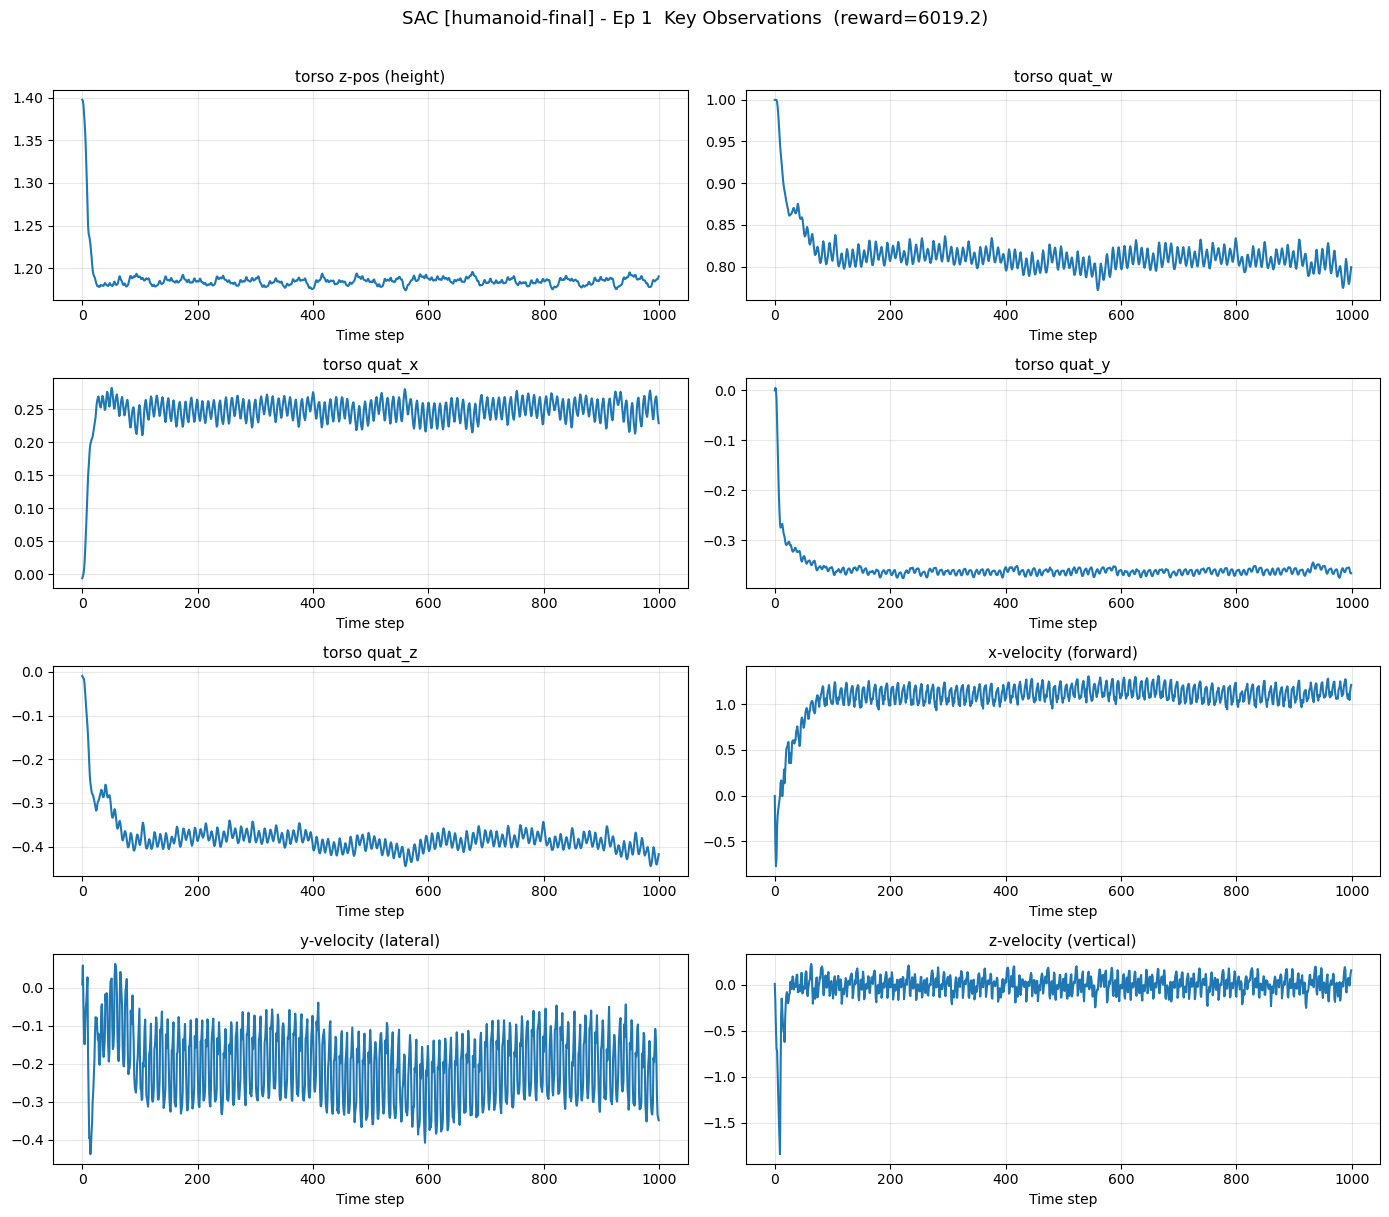

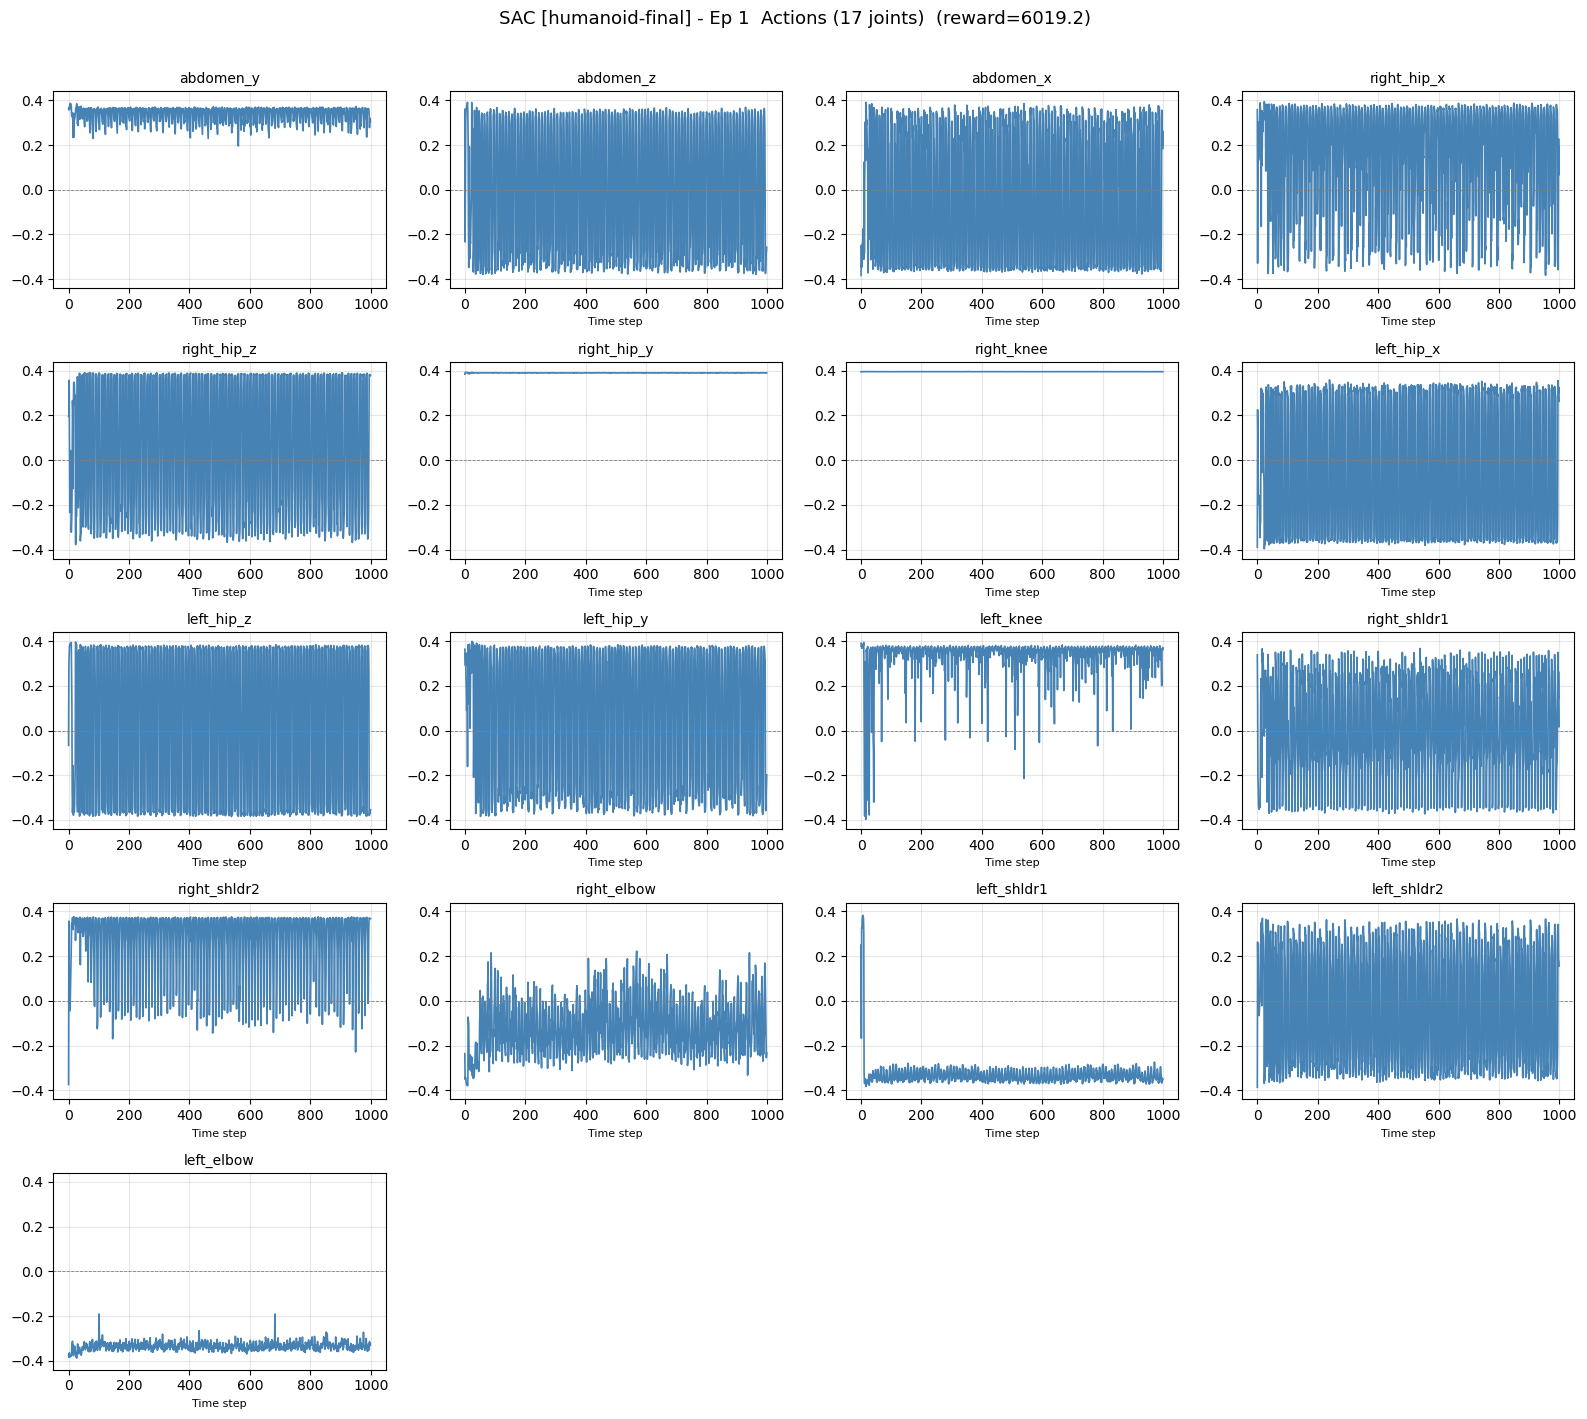

  obs -> sac_humanoid_final_obs_ep1.png  |  act -> sac_humanoid_final_act_ep1.png

Episode  2/5 | reward:   6009.2 | steps: 1000


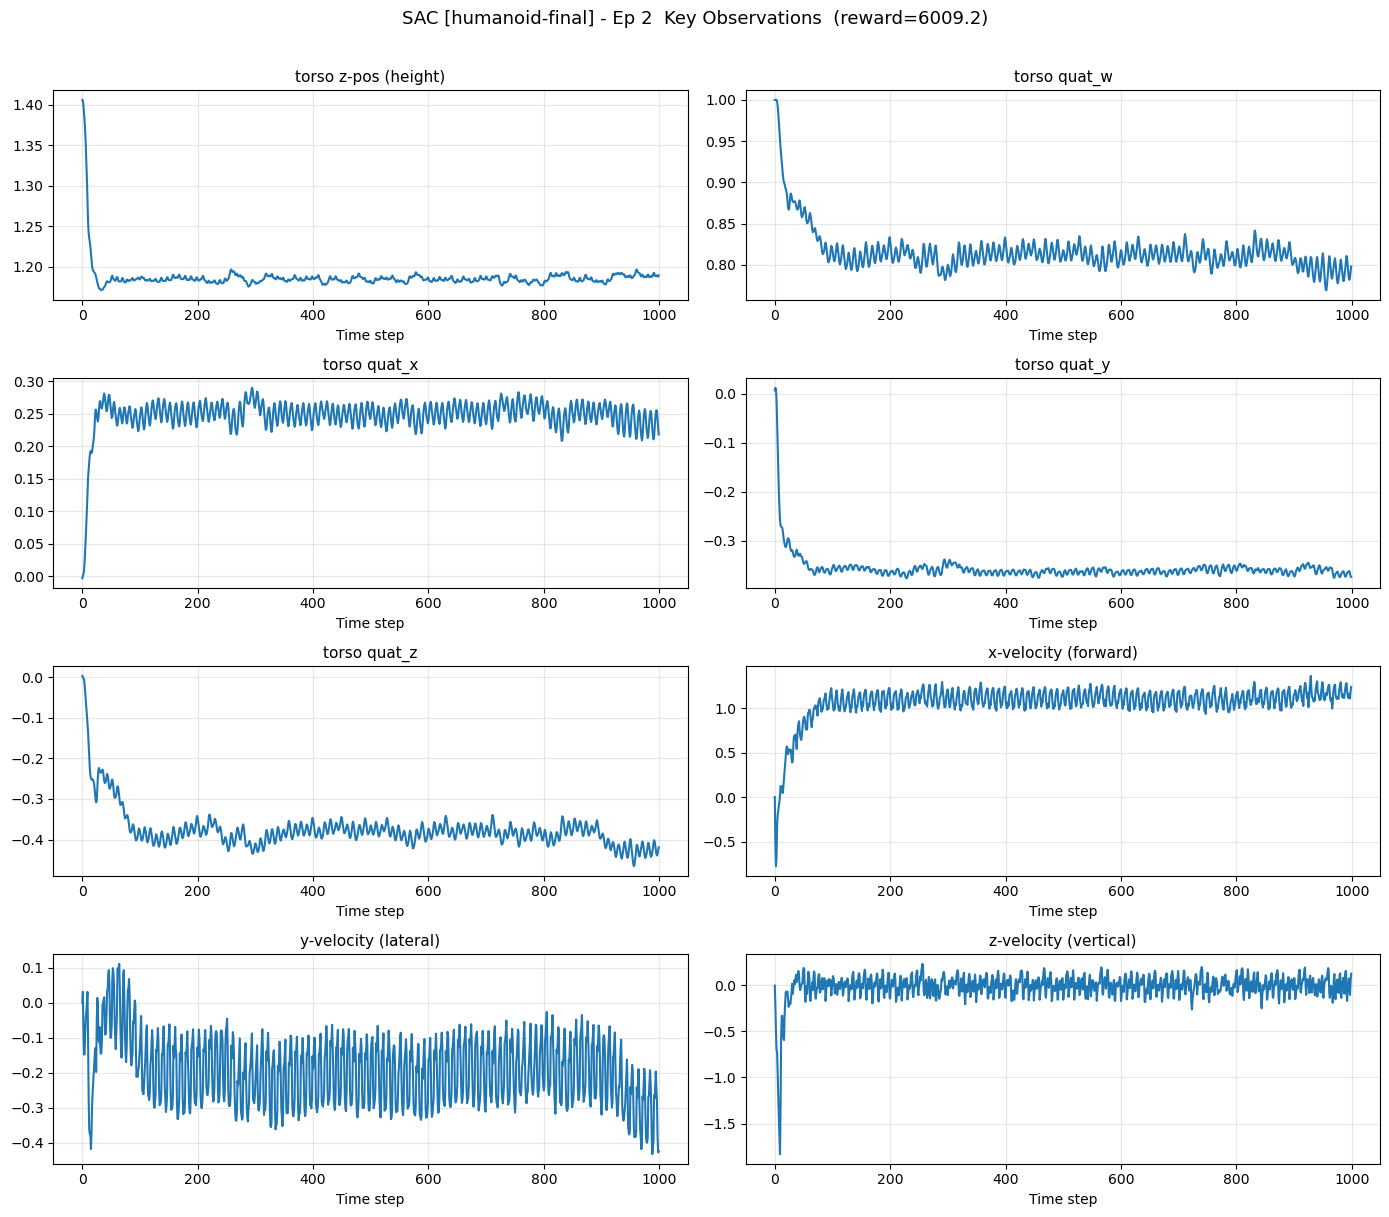

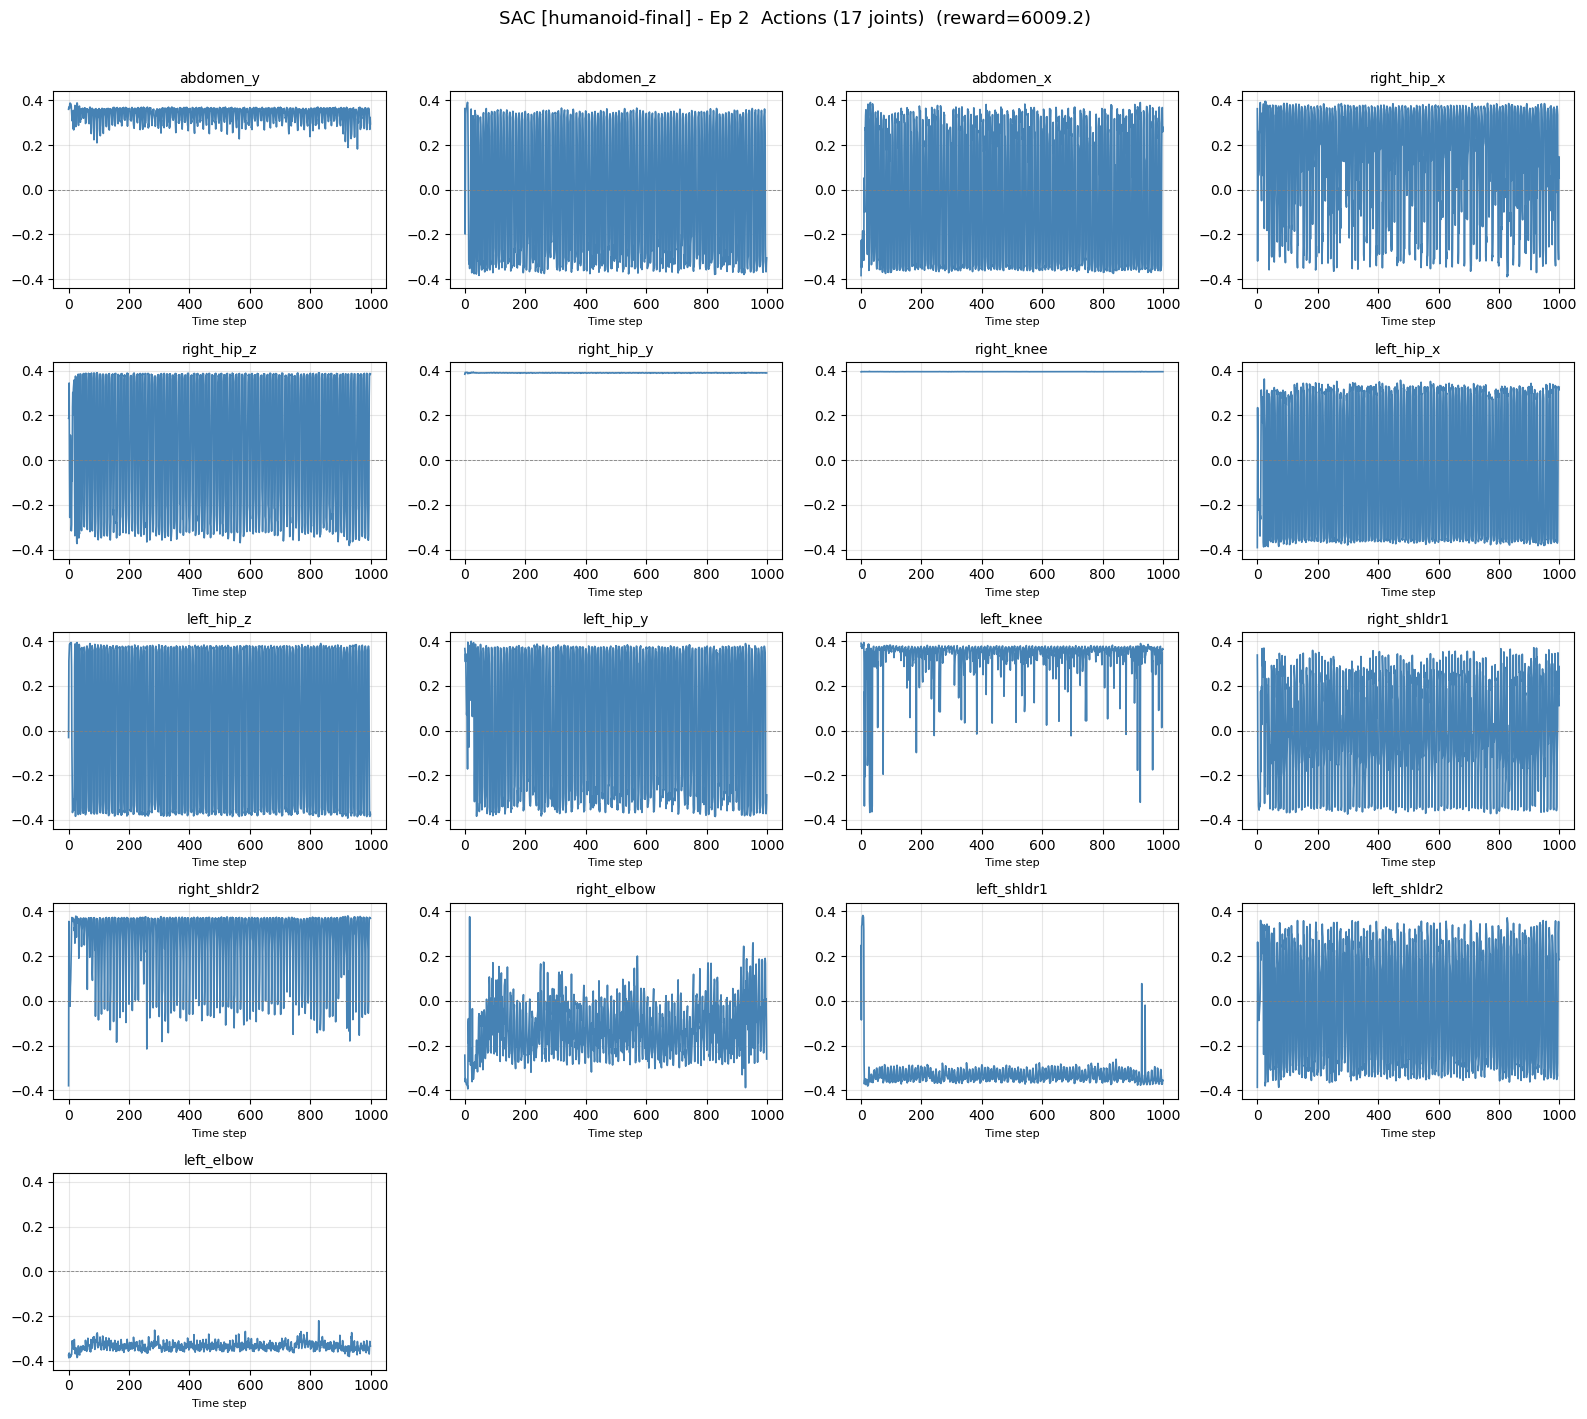

  obs -> sac_humanoid_final_obs_ep2.png  |  act -> sac_humanoid_final_act_ep2.png



c:\Users\GSKIM\anaconda3\Lib\site-packages\glfw\__init__.py:917: GLFWError: (65537) b'The GLFW library is not initialized'
  warnings.warn(message, GLFWError)


Episode  3/5 | reward:   6000.0 | steps: 1000


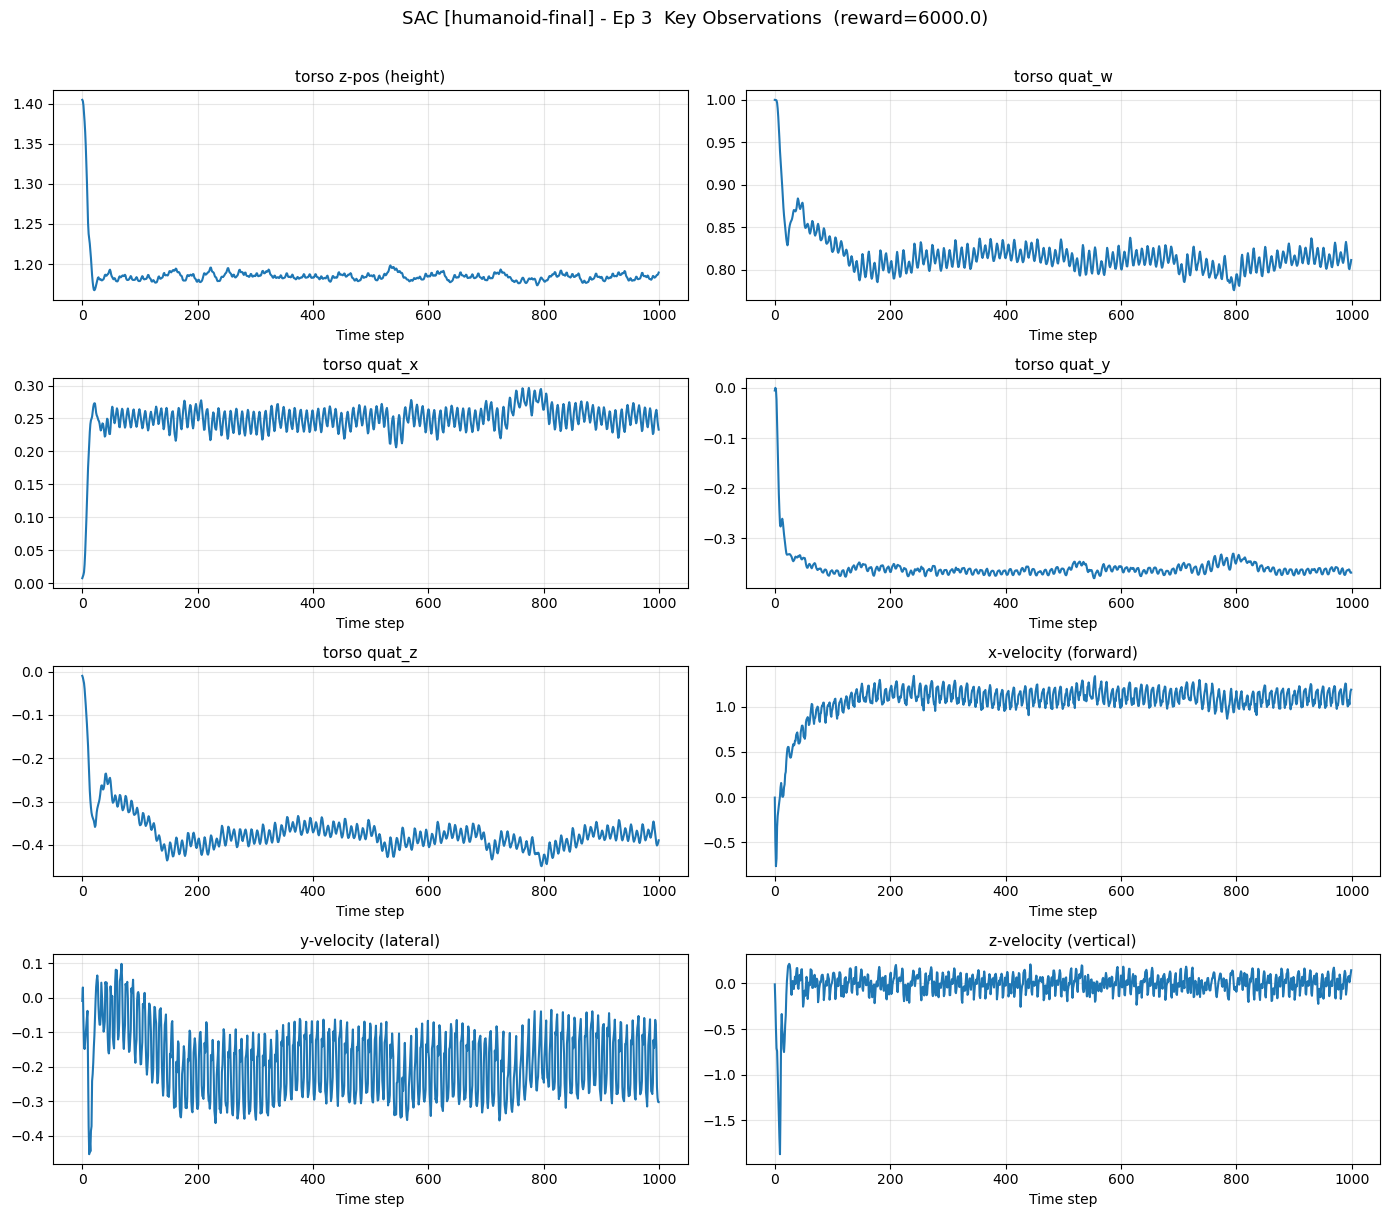

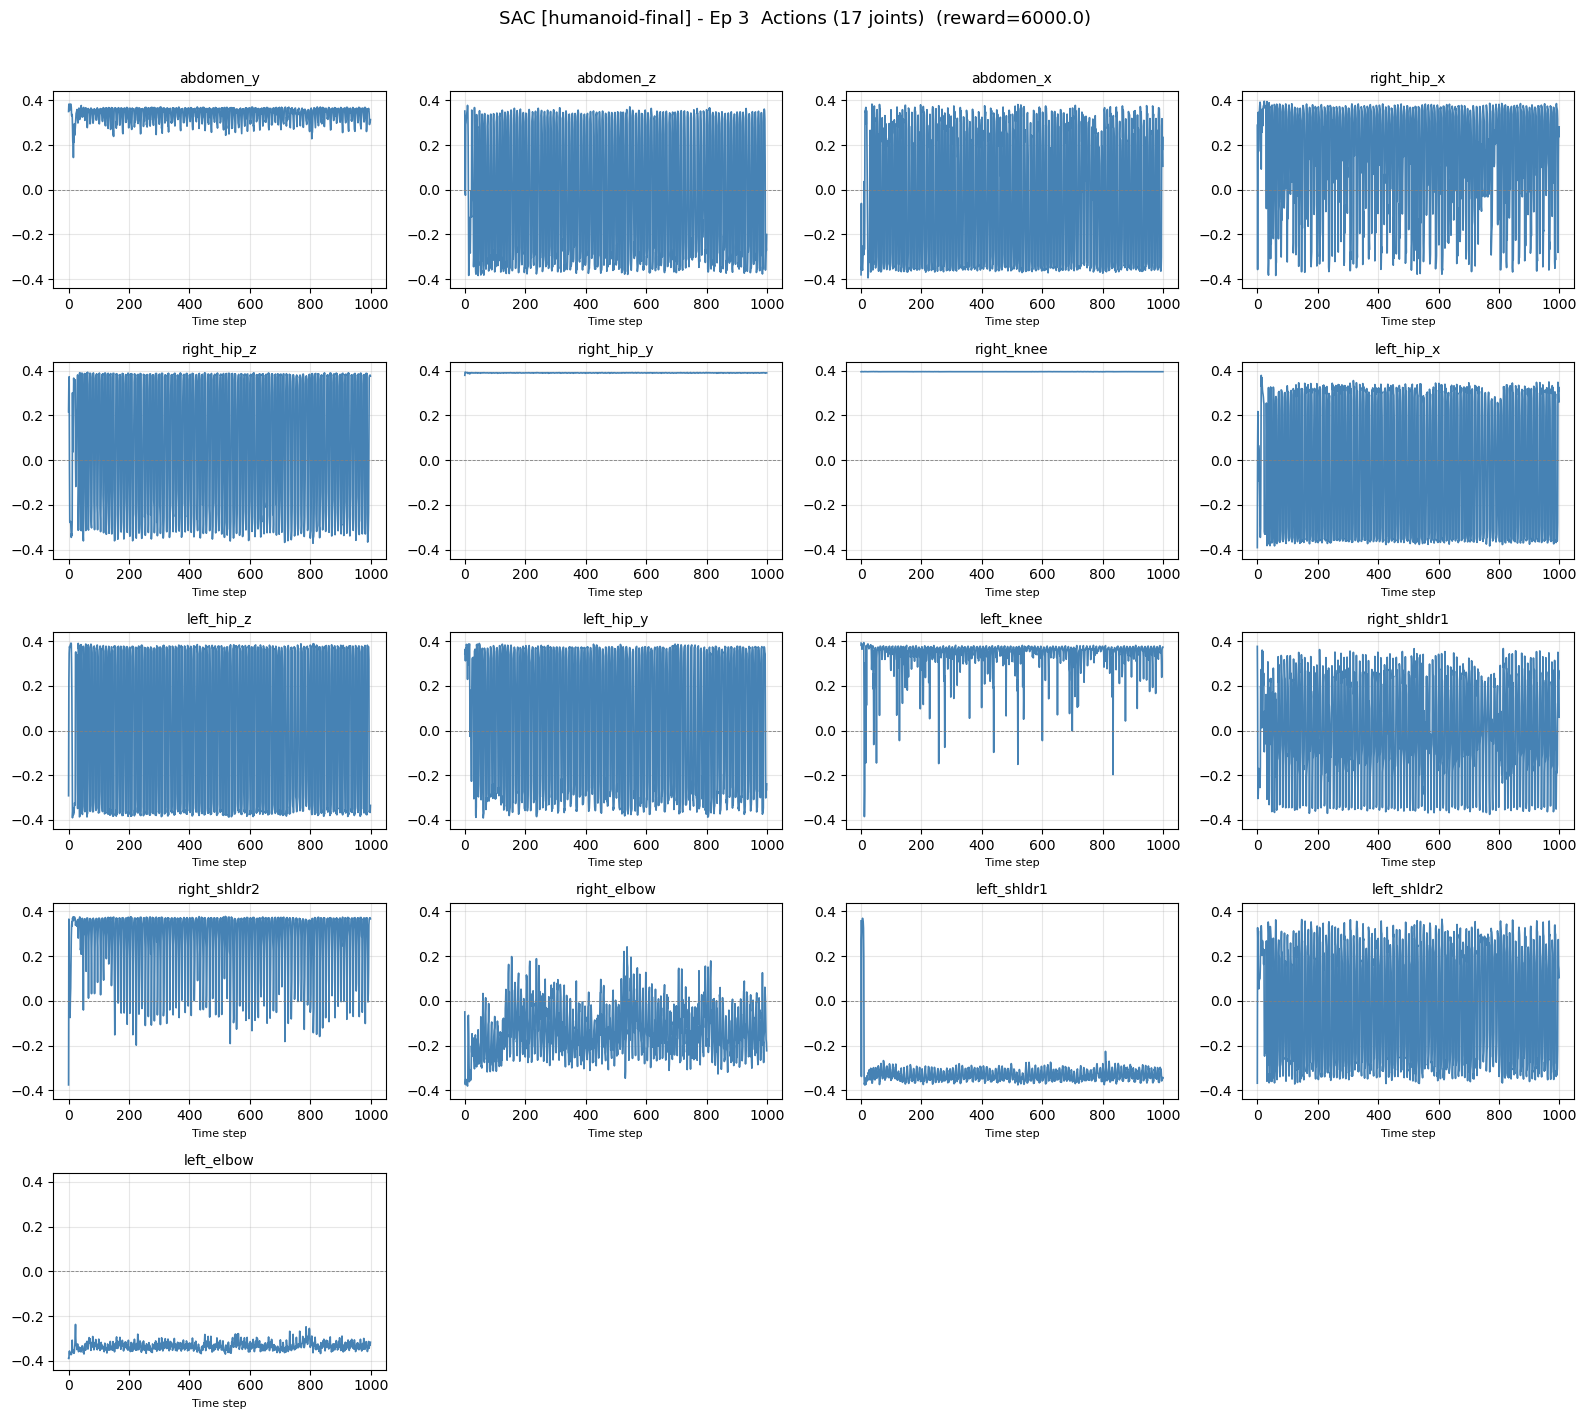

  obs -> sac_humanoid_final_obs_ep3.png  |  act -> sac_humanoid_final_act_ep3.png

Episode  4/5 | reward:   6004.2 | steps: 1000


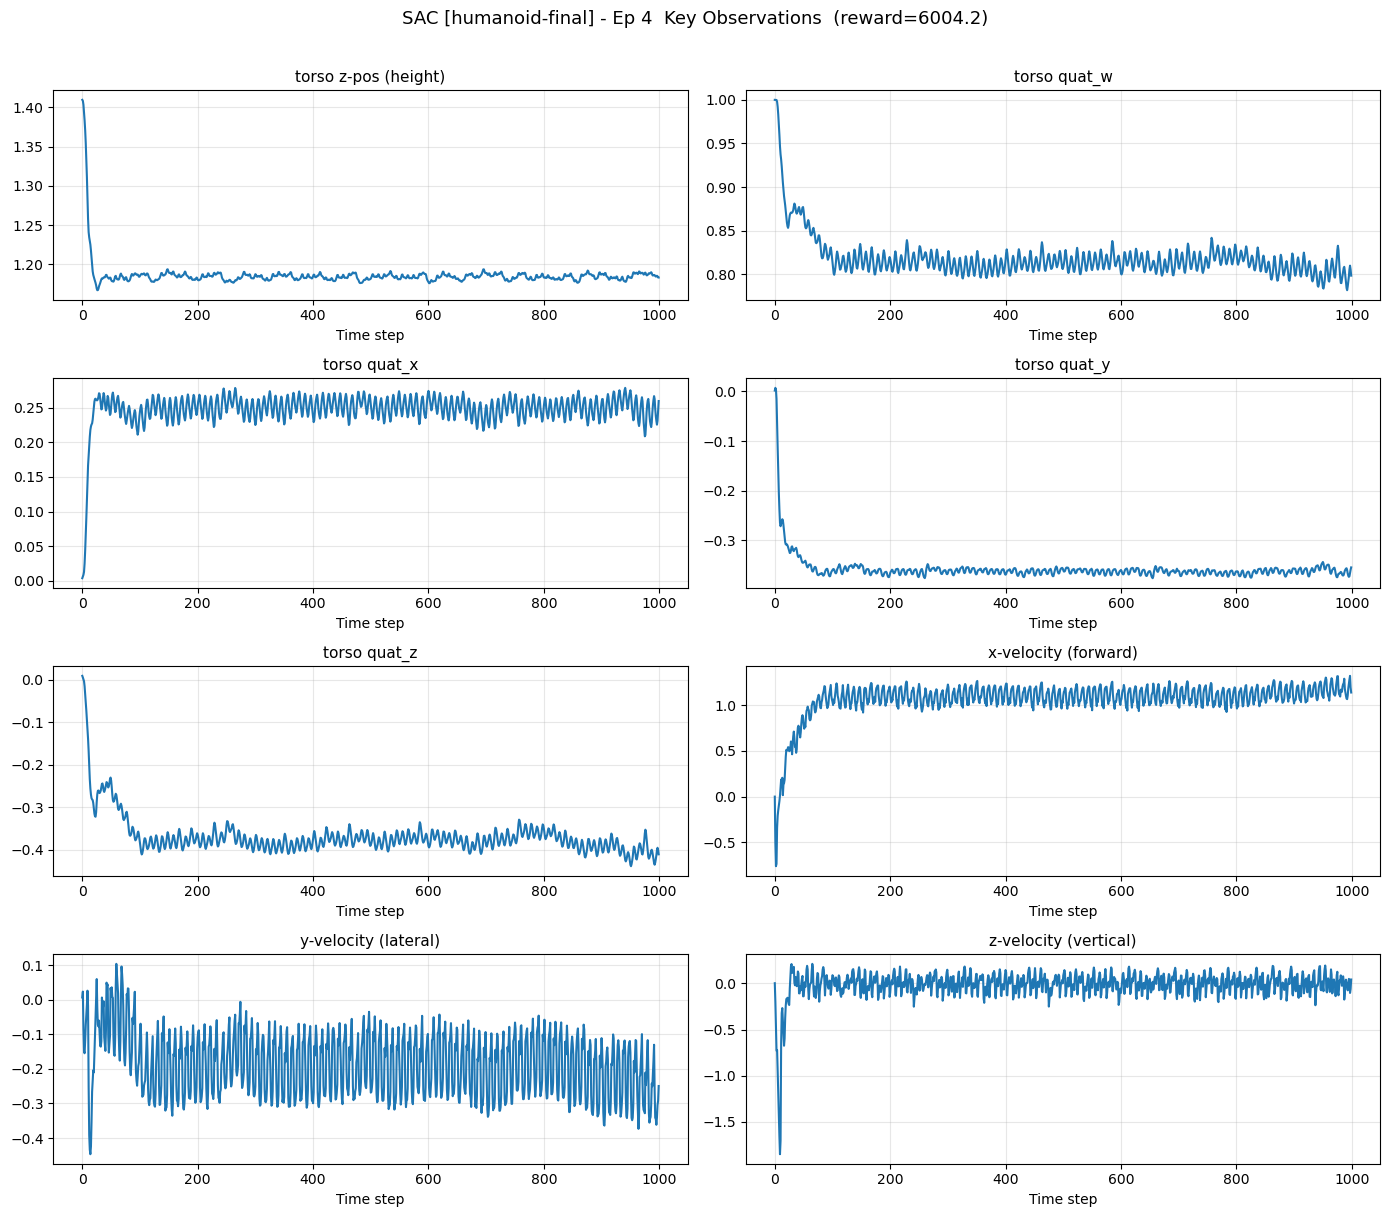

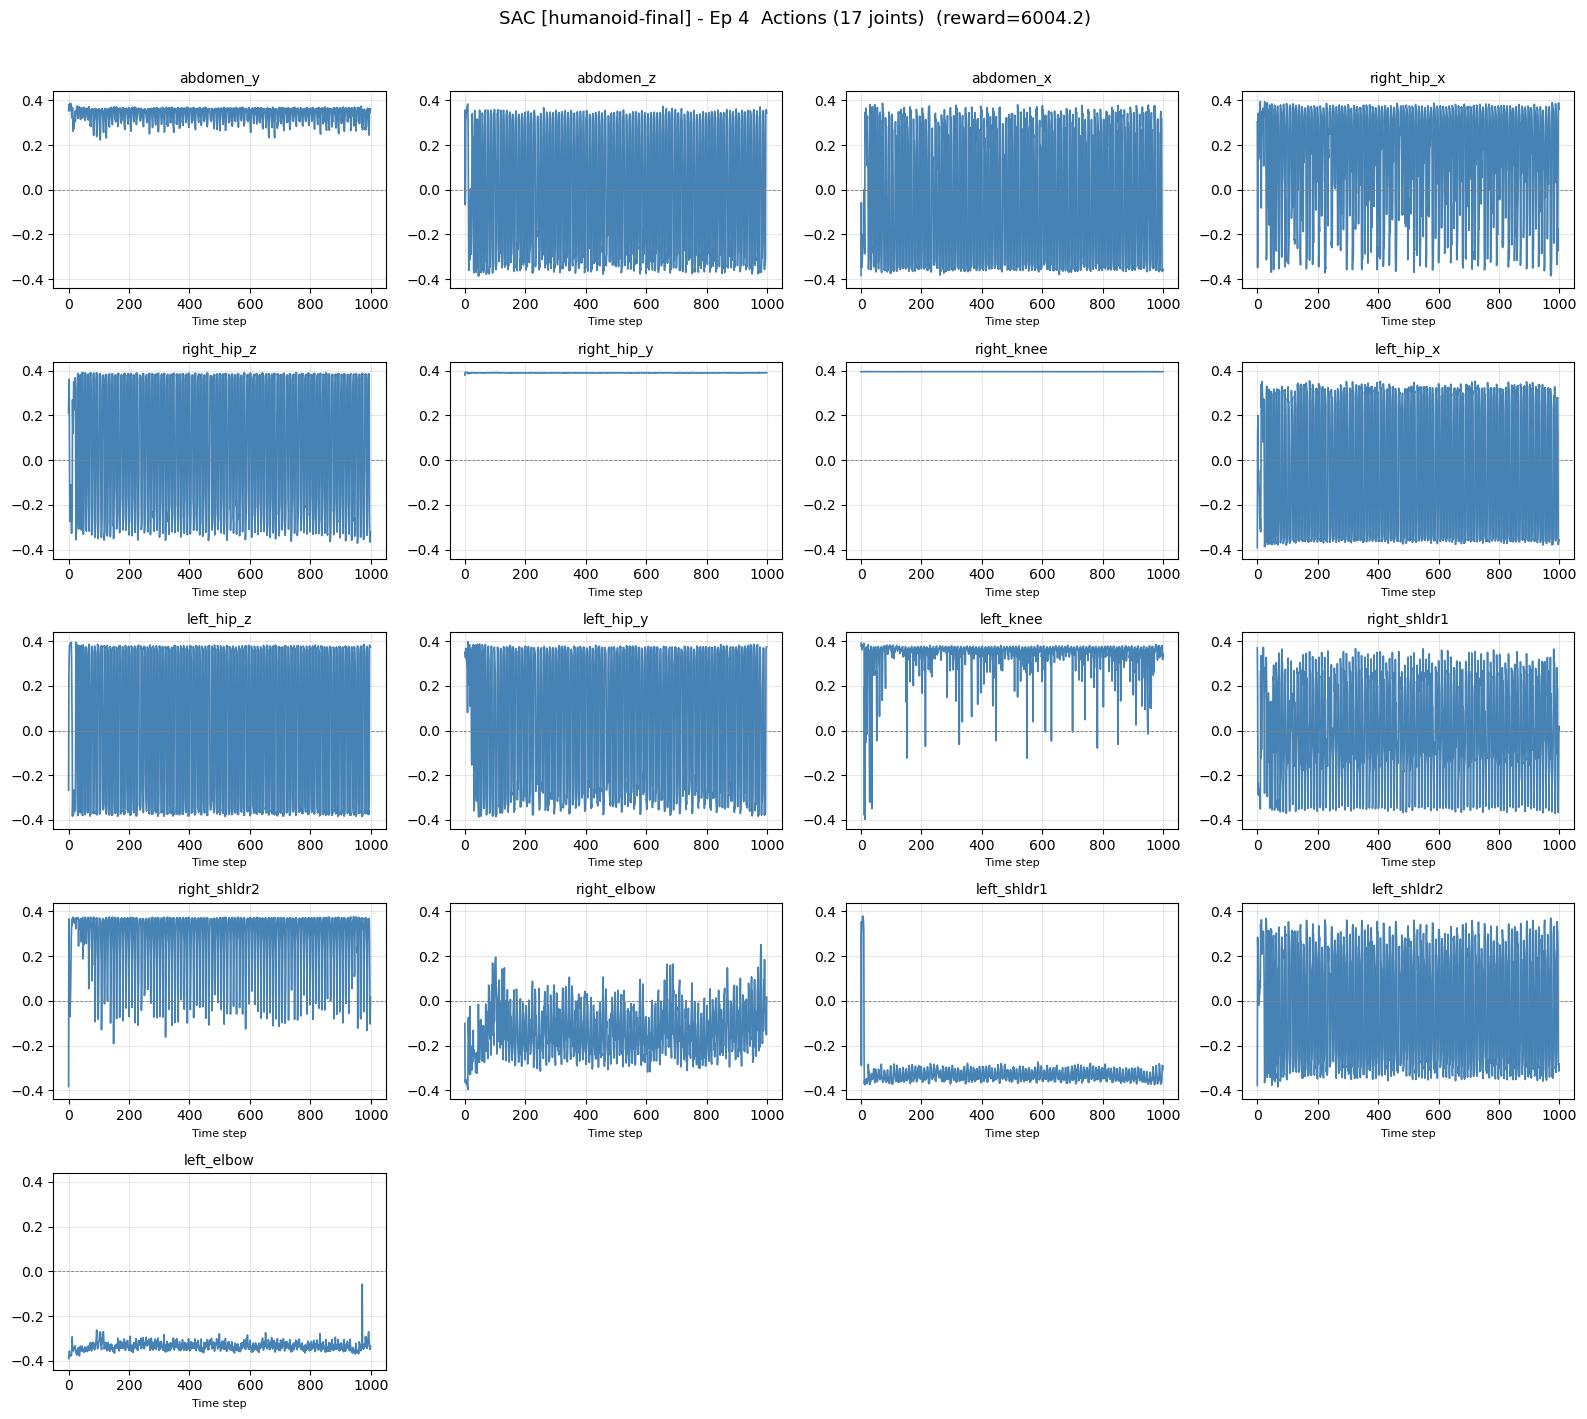

  obs -> sac_humanoid_final_obs_ep4.png  |  act -> sac_humanoid_final_act_ep4.png

Episode  5/5 | reward:   5992.8 | steps: 1000


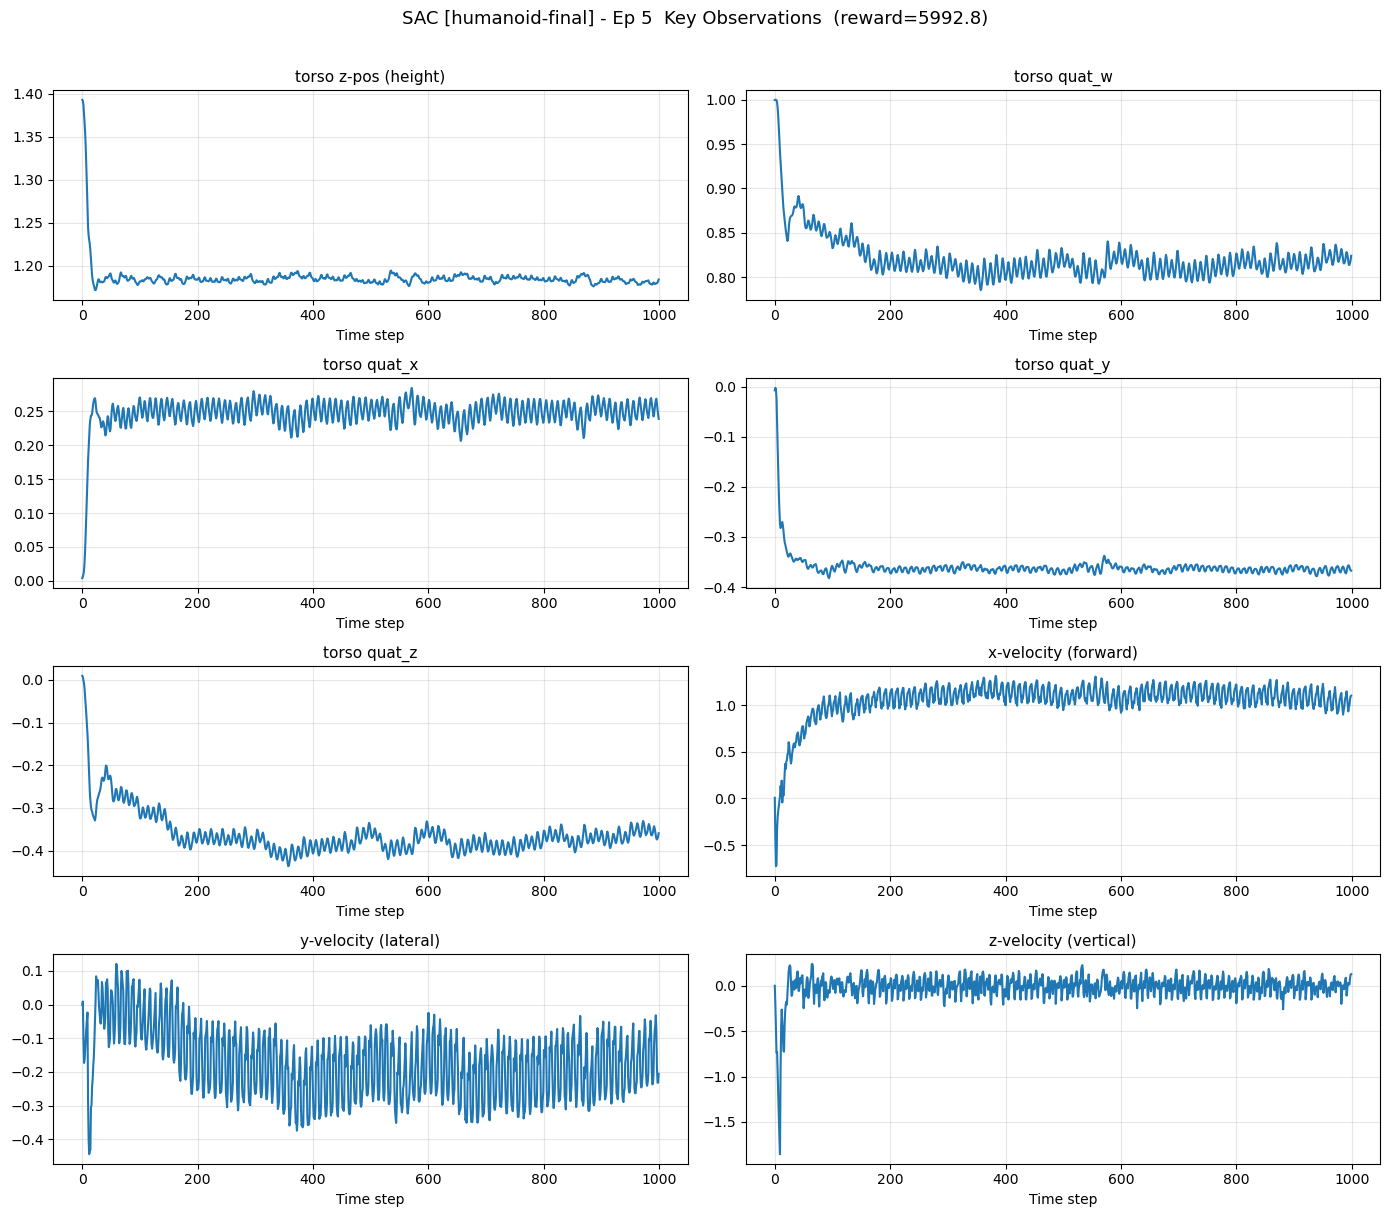

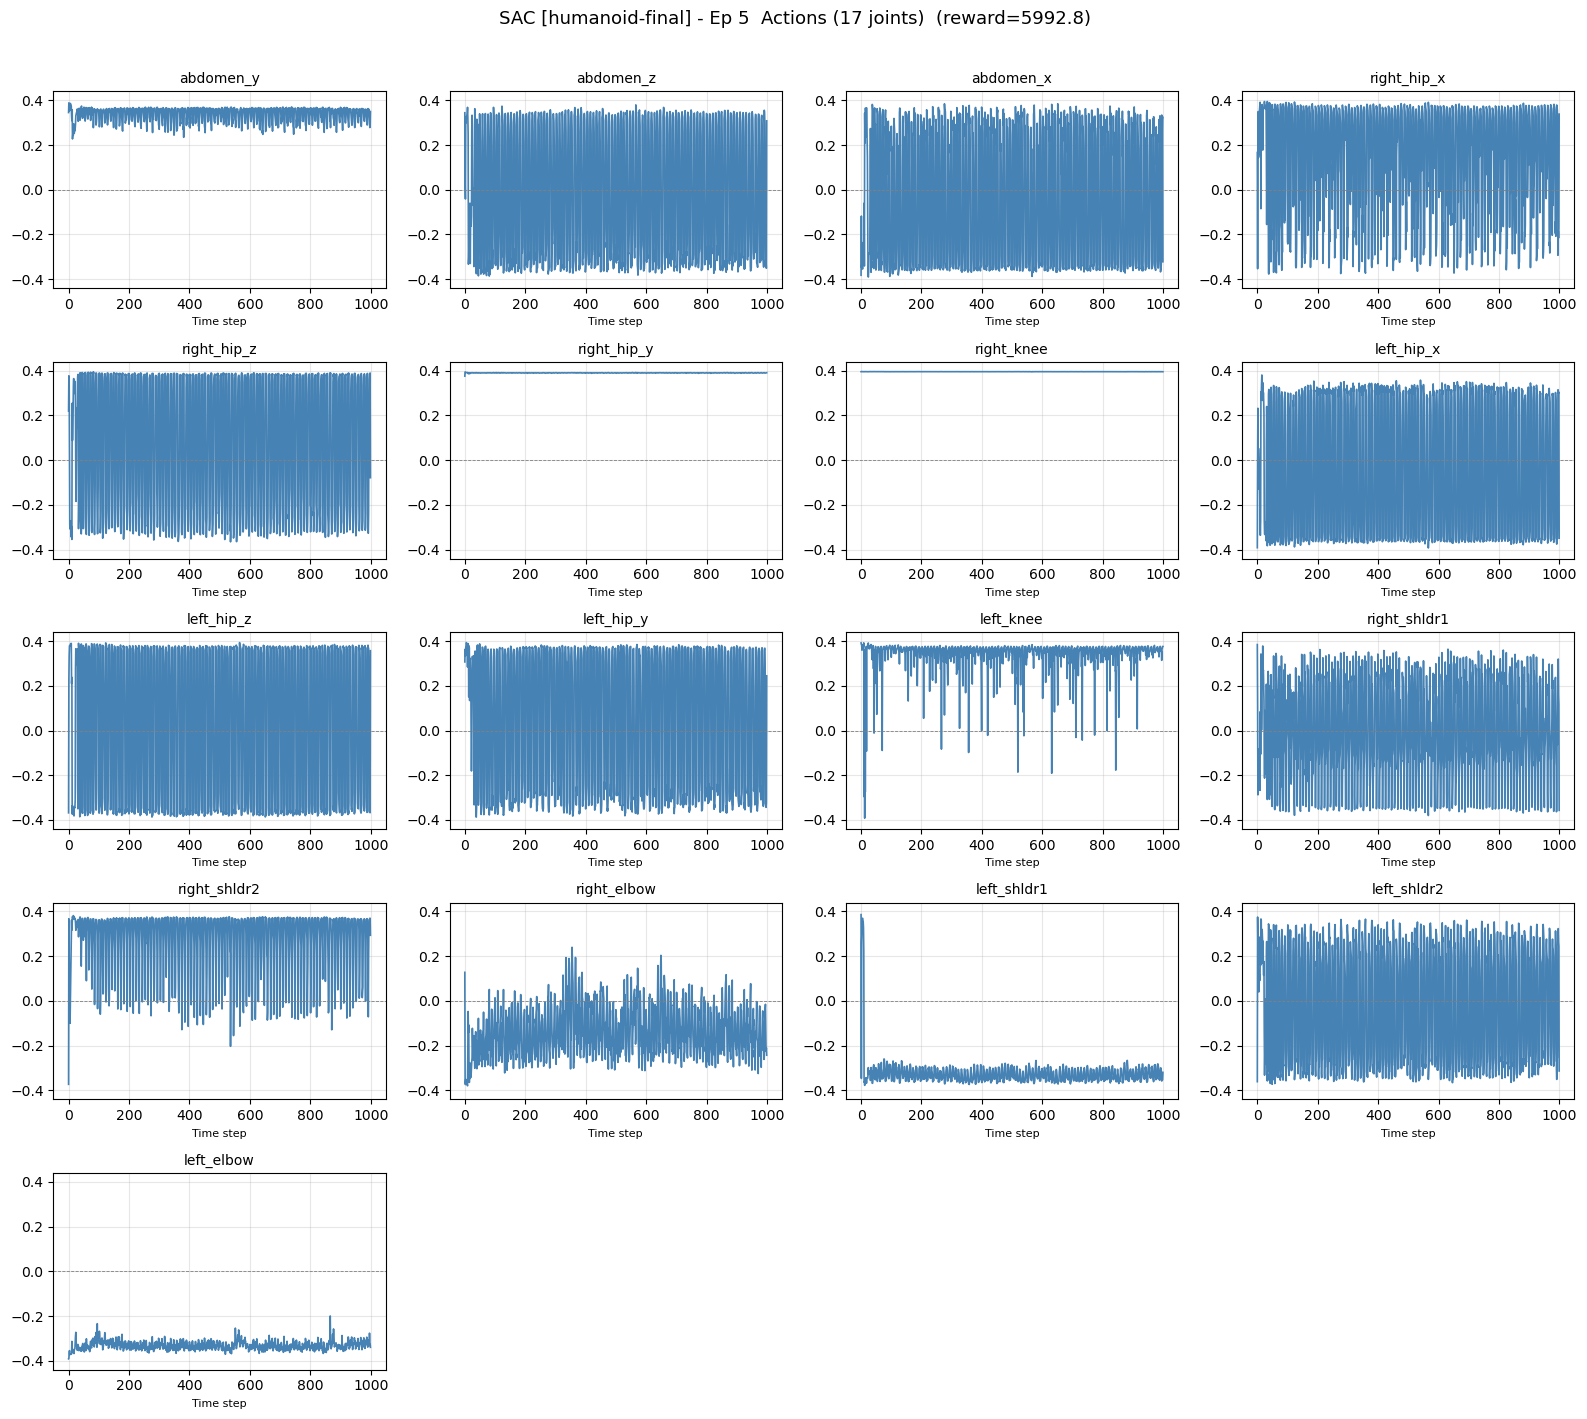

  obs -> sac_humanoid_final_obs_ep5.png  |  act -> sac_humanoid_final_act_ep5.png

Done.


In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║     SAC  ·  MuJoCo Humanoid-v5  ·  INFERENCE                   ║
# ╚══════════════════════════════════════════════════════════════════╝
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ── Config (must match training) ──────────────────────────────────────────────
STATE_DIM  = 348       # Humanoid-v5 observation space (v4: 376 → v5: 348)
ACTION_DIM = 17
MAX_ACTION = 0.4

FINAL_PATH = 'sac_humanoid_final.pt'
BEST_PATH  = 'sac_humanoid_best.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Actor (must match training) ───────────────────────────────────────────────
class Actor(nn.Module):
    LOG_STD_MIN = -20
    LOG_STD_MAX =   2

    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(STATE_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
        )
        self.mean_layer    = nn.Linear(256, ACTION_DIM)
        self.log_std_layer = nn.Linear(256, ACTION_DIM)

    def deterministic_action(self, s):
        x    = self.shared(s)
        mean = self.mean_layer(x)
        return MAX_ACTION * torch.tanh(mean)

# ── Inference ─────────────────────────────────────────────────────────────────
def run_inference(save_path=FINAL_PATH, n_episodes=5):
    env = gym.make('Humanoid-v5', render_mode='human')

    actor = Actor().to(device)
    ckpt  = torch.load(save_path, map_location=device)
    actor.load_state_dict(ckpt['actor'])
    actor.eval()

    model_tag   = 'final' if save_path == FINAL_PATH else 'best'
    saved_alpha = np.exp(ckpt['log_alpha'])
    print(f'[{model_tag}] actor loaded from {save_path}')
    print(f'  saved alpha: {saved_alpha:.4f}')
    print(f'Running {n_episodes} episodes (deterministic)...\n')

    # Key observation indices (8 out of 348)
    # Humanoid-v5 obs (exclude_current_positions=True):
    #   [0]   : torso z-pos (height)
    #   [1-4] : torso quaternion
    #   [22-24]: translational velocities (dx, dy, dz)
    key_obs_idx    = [0, 1, 2, 3, 4, 22, 23, 24]
    key_obs_labels = [
        'torso z-pos (height)',
        'torso quat_w',
        'torso quat_x',
        'torso quat_y',
        'torso quat_z',
        'x-velocity (forward)',
        'y-velocity (lateral)',
        'z-velocity (vertical)',
    ]

    # 17 actuator names for Humanoid
    action_labels = [
        'abdomen_y', 'abdomen_z', 'abdomen_x',
        'right_hip_x', 'right_hip_z', 'right_hip_y', 'right_knee',
        'left_hip_x',  'left_hip_z',  'left_hip_y',  'left_knee',
        'right_shldr1', 'right_shldr2', 'right_elbow',
        'left_shldr1',  'left_shldr2',  'left_elbow',
    ]

    for ep in range(n_episodes):
        s, _         = env.reset()
        done         = False
        obs_history  = []
        act_history  = []
        total_reward = 0.0

        with torch.no_grad():
            while not done:
                obs_history.append(s.copy())
                s_t  = torch.FloatTensor(s).unsqueeze(0).to(device)
                a    = actor.deterministic_action(s_t).cpu().numpy().flatten()
                act_history.append(a.copy())
                s, r, done, truncated, _ = env.step(a)
                done = done or truncated
                total_reward += r

        steps = len(obs_history)
        print(f'Episode {ep+1:2d}/{n_episodes} | reward: {total_reward:8.1f} | steps: {steps}')

        obs = np.array(obs_history)   # (T, 348)
        act = np.array(act_history)   # (T, 17)
        t   = np.arange(steps)

        # ── Key Observation plot (4×2) ─────────────────────────────────────────
        fig, axes = plt.subplots(4, 2, figsize=(14, 12))
        for ax, idx, label in zip(axes.flatten(), key_obs_idx, key_obs_labels):
            ax.plot(t, obs[:, idx], linewidth=1.5)
            ax.set_title(label, fontsize=11)
            ax.set_xlabel('Time step')
            ax.grid(True, alpha=0.3)
        plt.suptitle(
            f'SAC [humanoid-{model_tag}] - Ep {ep+1}  Key Observations  (reward={total_reward:.1f})',
            fontsize=13, y=1.01)
        plt.tight_layout()
        obs_path = f'sac_humanoid_{model_tag}_obs_ep{ep+1}.png'
        plt.savefig(obs_path, dpi=150, bbox_inches='tight')
        plt.show()

        # ── Action plot (5×4 grid, 17 joints) ─────────────────────────────────
        fig, axes = plt.subplots(5, 4, figsize=(16, 14))
        axes_flat = axes.flatten()
        for i, (ax, label) in enumerate(zip(axes_flat[:ACTION_DIM], action_labels)):
            ax.plot(t, act[:, i], linewidth=1.2, color='steelblue')
            ax.set_title(label, fontsize=10)
            ax.set_xlabel('Time step', fontsize=8)
            ax.set_ylim(-MAX_ACTION * 1.1, MAX_ACTION * 1.1)
            ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
            ax.grid(True, alpha=0.3)
        for ax in axes_flat[ACTION_DIM:]:
            ax.set_visible(False)
        plt.suptitle(
            f'SAC [humanoid-{model_tag}] - Ep {ep+1}  Actions (17 joints)  (reward={total_reward:.1f})',
            fontsize=13, y=1.01)
        plt.tight_layout()
        act_path = f'sac_humanoid_{model_tag}_act_ep{ep+1}.png'
        plt.savefig(act_path, dpi=150, bbox_inches='tight')
        plt.show()

        print(f'  obs -> {obs_path}  |  act -> {act_path}\n')

    env.close()
    print('Done.')

# ── 실행 ──────────────────────────────────────────────────────────────────────
run_inference(save_path=FINAL_PATH)       # 최종 모델, 5 에피소드
# run_inference(save_path=BEST_PATH)      # best 모델로 추론하려면 이 줄 실행

In [3]:
%pip uninstall -y mujoco gymnasium
%pip install --upgrade pip
%pip install "gymnasium[mujoco]"

Found existing installation: mujoco 3.1.6
Uninstalling mujoco-3.1.6:
  Successfully uninstalled mujoco-3.1.6
Found existing installation: gymnasium 1.3.0
Uninstalling gymnasium-1.3.0:
  Successfully uninstalled gymnasium-1.3.0
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.




  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached mujoco-3.8.1-cp311-cp311-win_amd64.whl.metadata (43 kB)
Using cached gymnasium-1.3.0-py3-none-any.whl (953 kB)
Using cached mujoco-3.8.1-cp311-cp311-win_amd64.whl (5.8 MB)

   ---------------------------------------- 0/2 [gymnasium]
   ---------------------------------------- 0/2 [gymnasium]
   -------------------- ------------------- 1/2 [mujoco]
   -------------------- ------------------- 1/2 [mujoco]
   -------------------- ------------------- 1/2 [mujoco]
   ---------------------------------------- 2/2 [mujoco]



In [4]:
%pip uninstall -y mujoco
%pip install mujoco==3.1.6

Found existing installation: mujoco 3.8.1
Uninstalling mujoco-3.8.1:
  Successfully uninstalled mujoco-3.8.1
Note: you may need to restart the kernel to use updated packages.
  Using cached mujoco-3.1.6-cp311-cp311-win_amd64.whl.metadata (45 kB)
Using cached mujoco-3.1.6-cp311-cp311-win_amd64.whl (3.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
import mujoco
print(mujoco.__version__)

3.1.6
